# RR1/RR3 protocol-robust response comparison

This notebook asks what survives technical remeasurement in RR1 and how that compares with RR3-39 and RR3-40. Every response is **mean(FLT) − mean(GC)**. It reuses matched animals and frozen outputs; BridgeRNA inference and Integrated Gradients were not rerun.

“Robust” below means concordant across the specified original/remeasurement pair. It does **not** mean protocol-independent, causal, or independently biologically replicated.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == 'rr1_rr3_robust_response_comparison': ROOT = ROOT.parents[1]
B = ROOT/'benchmarks/rr1_rr3_robust_response_comparison'
R = B/'results'
pd.set_option('display.max_colwidth', 100)
print('Benchmark:', B)

Benchmark: /home/walt/bridge-rna/benchmarks/rr1_rr3_robust_response_comparison


## 1. Cohorts and exact technical counterparts

RR1 compares OSD-48 with OSD-168; RR3 compares the matched 39-day and 40-day OSD-137 strata with OSD-168. The table below records sample counts, animals, library preparation, sequencing configuration, preservation, strain, sex, and RIN where available. These are technical remeasurements of matched biological material—not new biological replicates.

In [2]:
meta = pd.read_csv(R/'manifest/cohort_metadata_summary.csv')
display(meta.style.hide(axis='index').format({'RIN_median':'{:.2f}','RIN_min':'{:.2f}','RIN_max':'{:.2f}'}, na_rep='—'))
animals = pd.read_csv(R/'manifest/exact_matched_animals.csv')
display(animals.groupby(['cohort','measurement','OSD','condition']).agg(n=('sample_id','nunique'), animals=('animal_id', lambda x: ', '.join(x))).reset_index().style.hide(axis='index'))

cohort,OSD,condition,n,animal_ids,library_preparation,sequencing_configuration,sequencing_facility,preservation,strain,sex,RIN_median,RIN_min,RIN_max
RR1 Ribo remeasurement,OSD-168,FLT,4,M25; M26; M28; M30,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,C57BL/6J,Female,9.05,8.10,9.10
RR1 Ribo remeasurement,OSD-168,GC,5,M36; M37; M38; M39; M40,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,C57BL/6J,Female,8.00,7.90,9.20
RR1 carcass,OSD-48,FLT,4,M25; M26; M28; M30,polyA,SE 50bp 30M,UC Davis,Mini Cold Bag to -80C freezer,C57BL/6J,Female,8.55,7.70,9.10
RR1 carcass,OSD-48,GC,5,M36; M37; M38; M39; M40,polyA,SE 50bp 30M,UC Davis,Mini Cold Bag to -80C freezer,C57BL/6J,Female,8.00,7.90,9.20
RR3-39,OSD-137,FLT,2,F1; F2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.30,7.30,7.30
RR3-39,OSD-137,GC,2,G1; G2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.20,7.10,7.30
RR3-39 technical remeasurement,OSD-168,FLT,2,F1; F2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.30,7.30,7.30
RR3-39 technical remeasurement,OSD-168,GC,2,G1; G2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.20,7.10,7.30
RR3-40,OSD-137,FLT,2,F3; F4,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.10,6.70,7.50
RR3-40,OSD-137,GC,2,G3; G5,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.35,6.90,7.80


cohort,measurement,OSD,condition,n,animals
RR1,original,OSD-48,FLT,4,"M25, M26, M28, M30"
RR1,original,OSD-48,GC,5,"M36, M37, M38, M39, M40"
RR1,remeasure,OSD-168,FLT,4,"M25, M26, M28, M30"
RR1,remeasure,OSD-168,GC,5,"M36, M37, M38, M39, M40"
RR3-39,original,OSD-137,FLT,2,"F1, F2"
RR3-39,original,OSD-137,GC,2,"G1, G2"
RR3-39,remeasure,OSD-168,FLT,2,"F1, F2"
RR3-39,remeasure,OSD-168,GC,2,"G1, G2"
RR3-40,original,OSD-137,FLT,2,"F3, F4"
RR3-40,original,OSD-137,GC,2,"G3, G5"


## 2. Primary comparison

The same definitions are used for all cohorts. Expression and signed IG robustness require mutual Top-500 membership and concordant sign. Graph robustness uses a positive Top-500 per-gene neighborhood-response cosine. Counts supported by ≥2 or all 3 evidence levels are intersections of these prespecified indicators, not learned scores.

In [3]:
primary = pd.read_csv(R/'summary/primary_comparison.csv', index_col=0)
display(primary.style.format('{:.3f}', na_rep='—'))

,RR1,RR3-39,RR3-40
metric,,,
3-level genes,26.000,15.000,31.000
Expression Spearman,0.425,0.618,0.673
Expression cosine,0.369,0.652,0.822
Global response cosine,-0.807,0.790,0.917
Graph response cosine,0.183,0.319,0.399
Hallmark cosine,-0.424,0.775,0.922
IG Spearman,0.194,0.601,0.597
IG cosine,0.727,0.867,0.725
Median local graph cosine,0.138,0.340,0.386


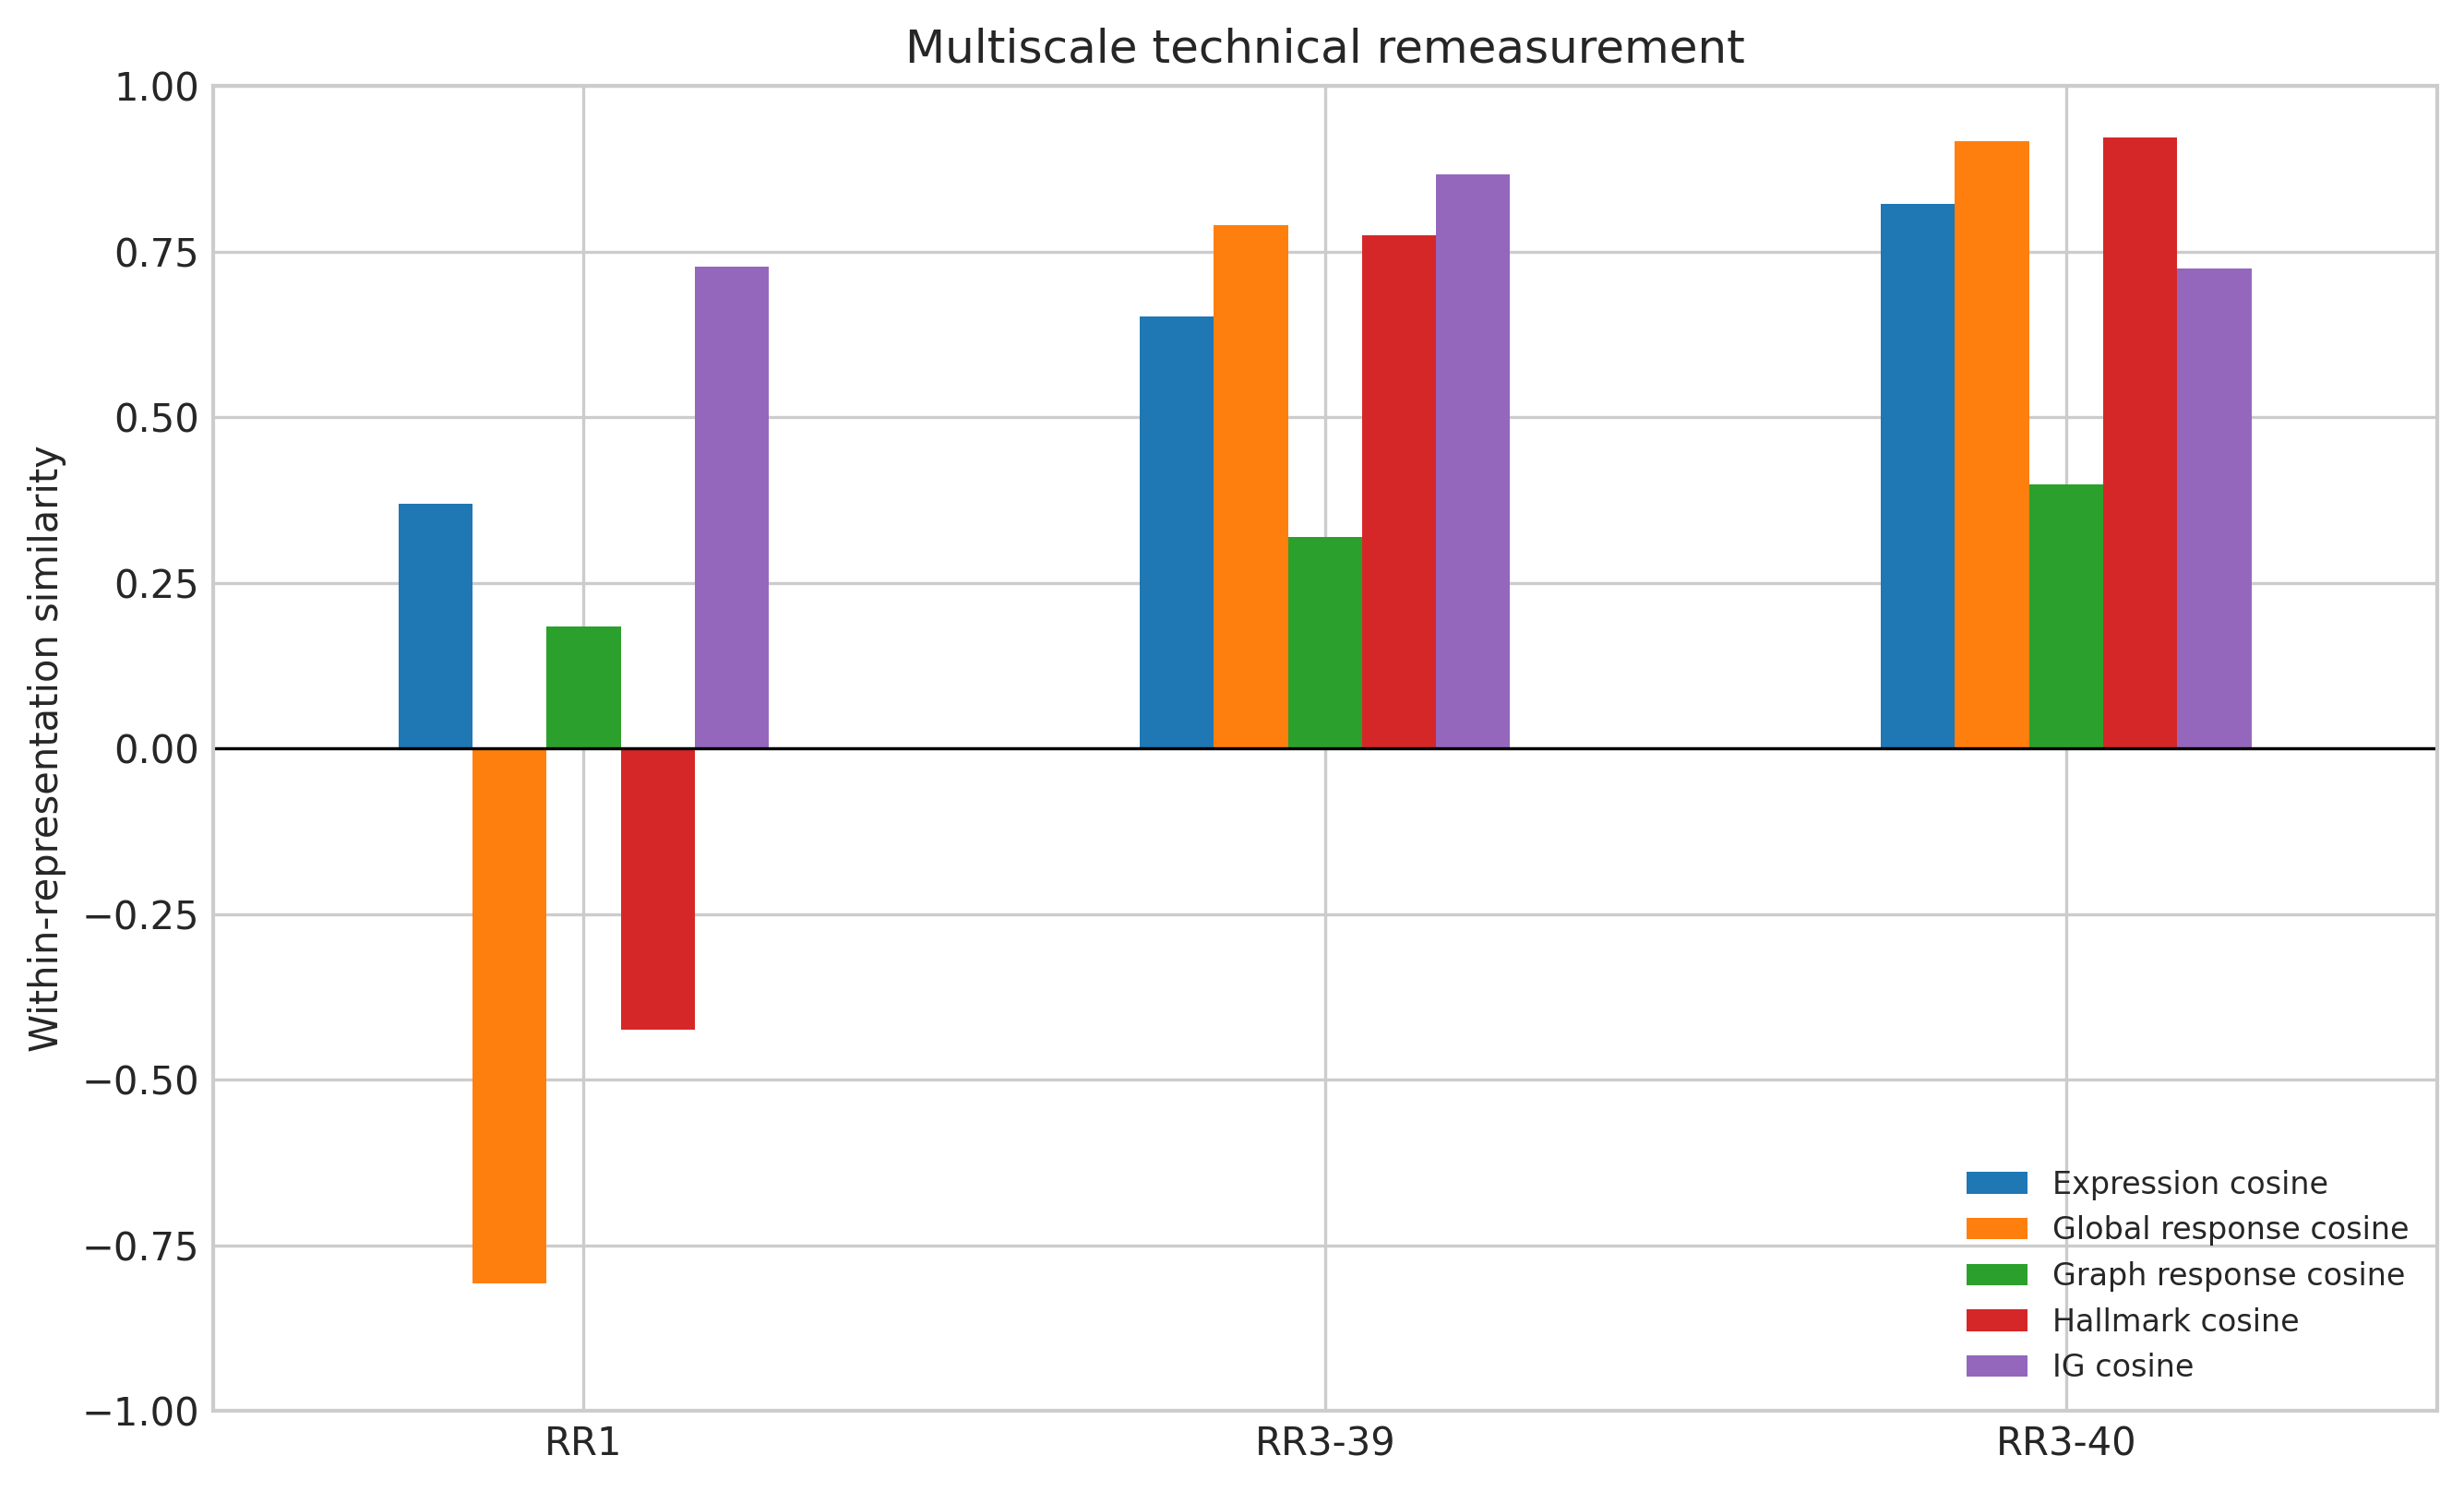

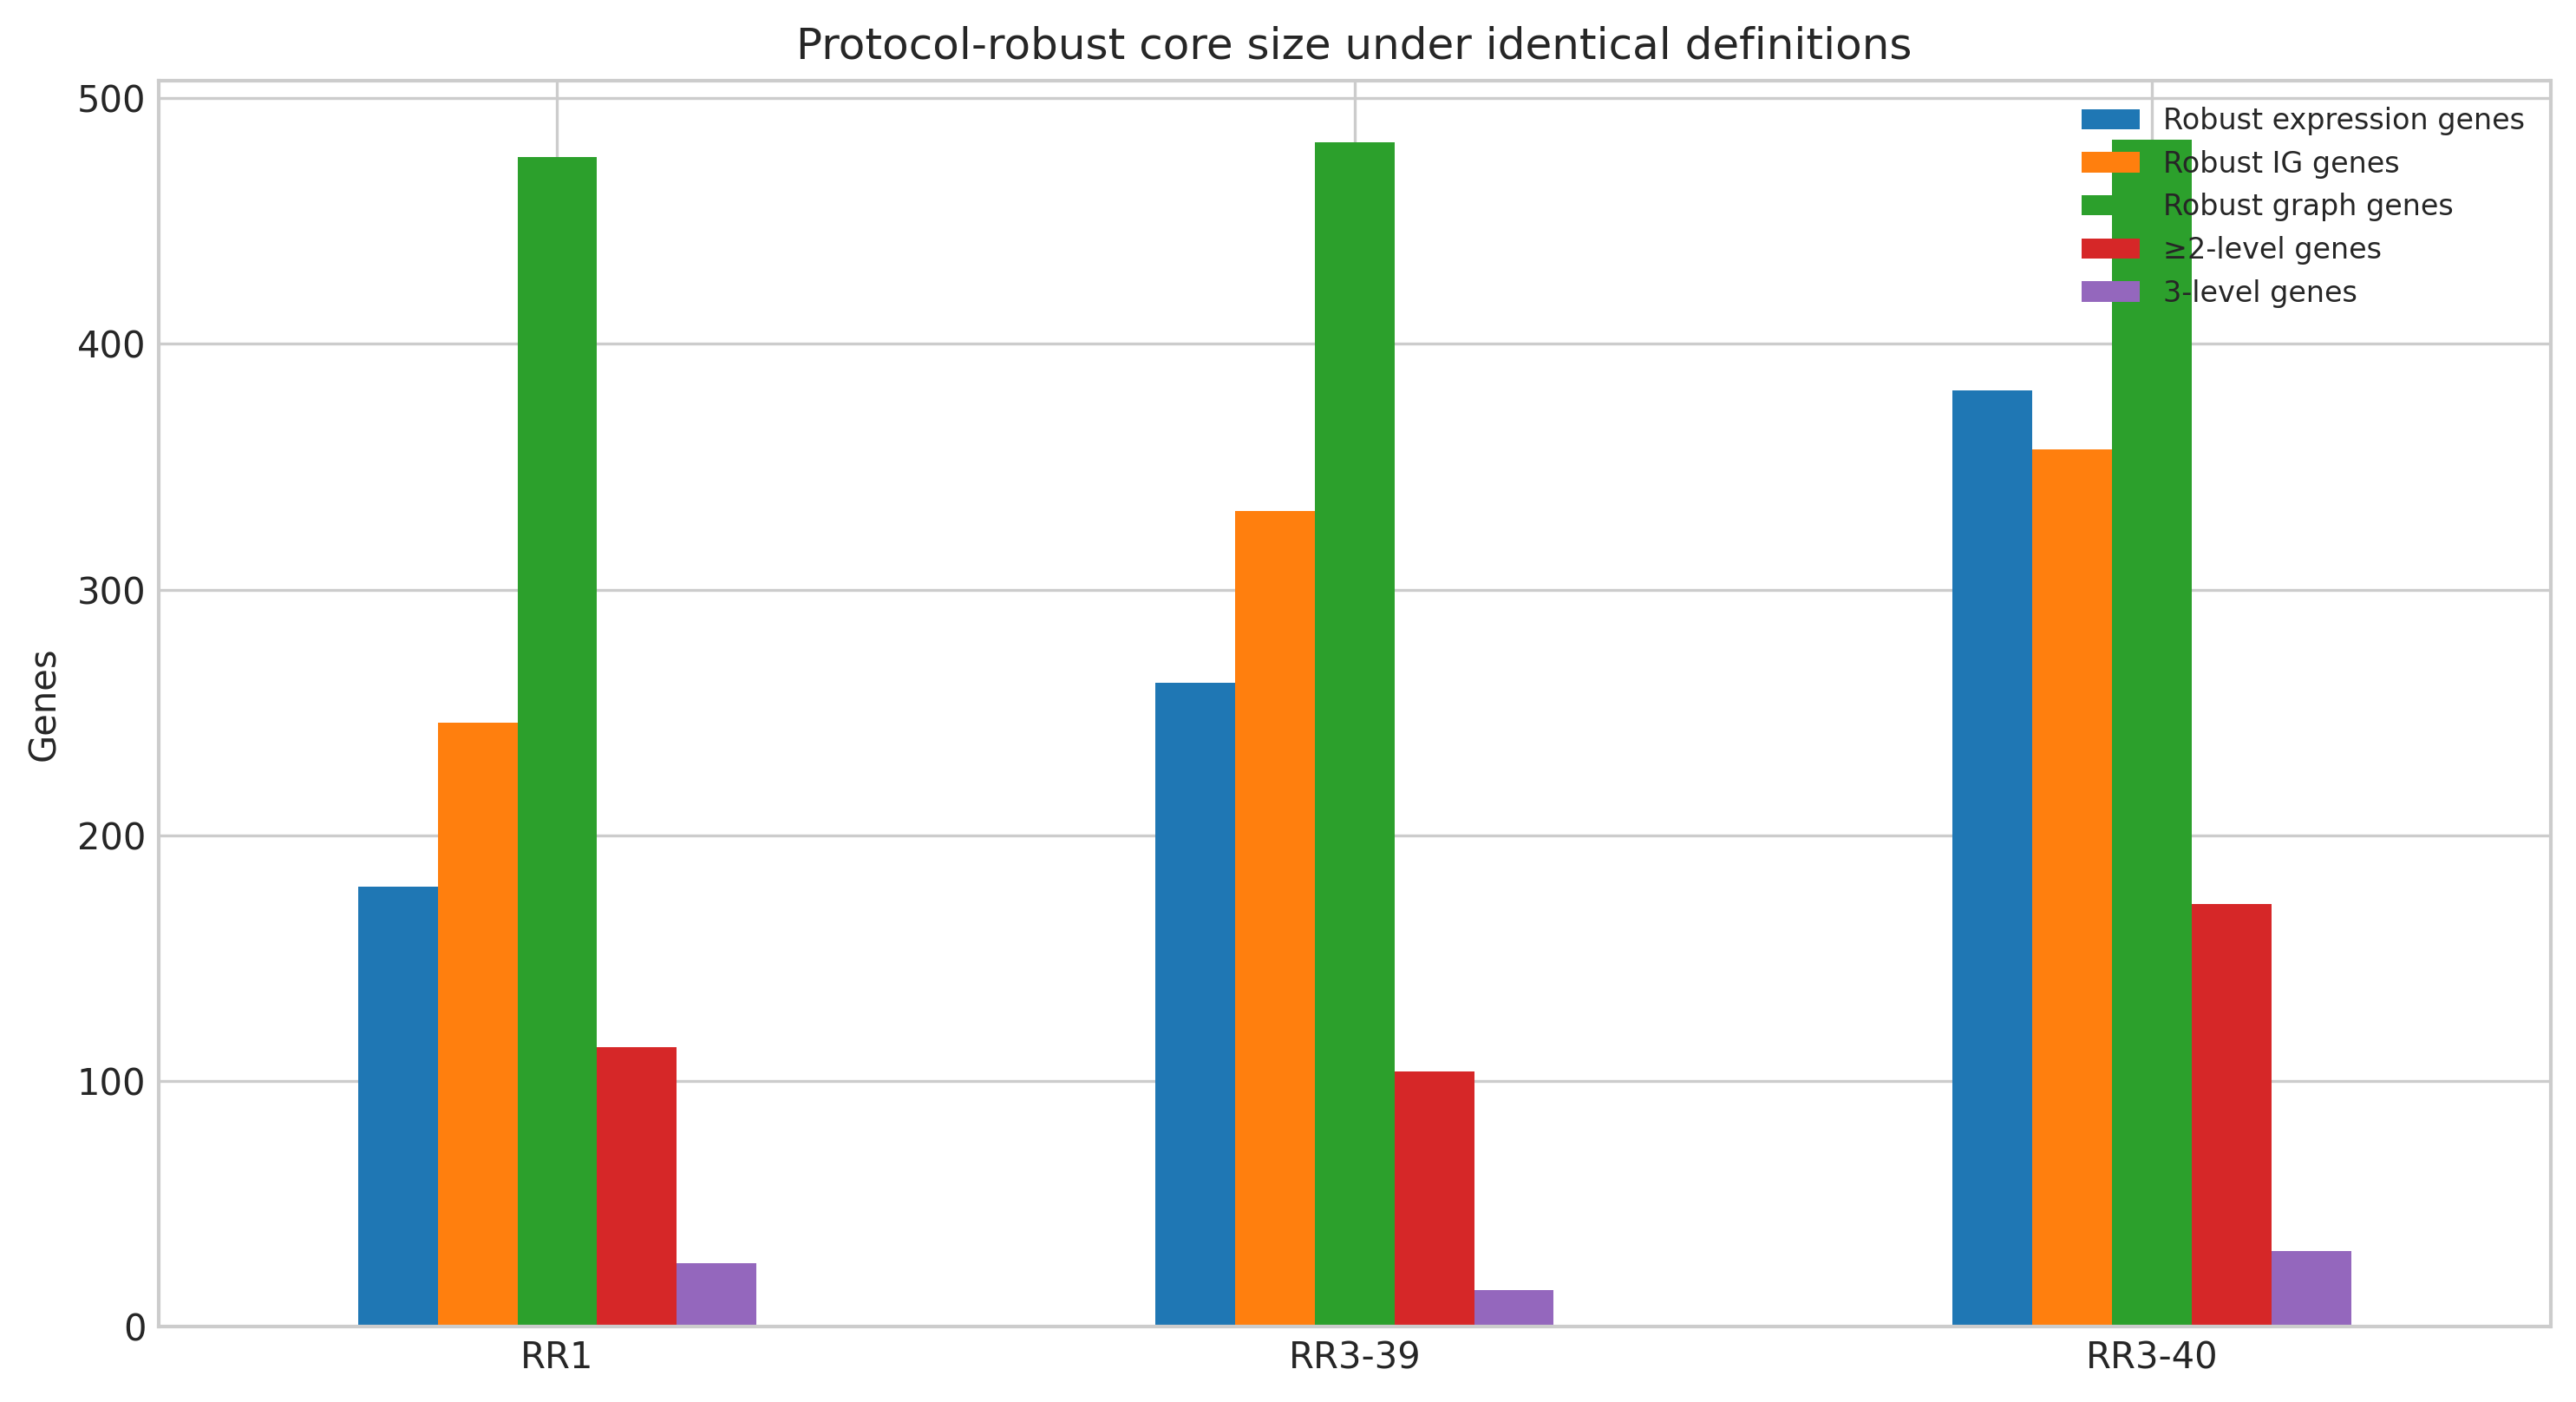

In [4]:
display(Image(filename=str(R/'figures/multiscale_reproducibility.png'), width=900))
display(Image(filename=str(R/'figures/robust_core_size.png'), width=900))

**Headline.** RR3-40 is the strongest technical replication: global response cosine 0.917, expression cosine 0.822, Hallmark cosine 0.922, and 172 genes supported by at least two levels. RR3-39 is moderate/good. RR1 reverses globally (−0.807) and at the Hallmark level (−0.424), with weaker expression, IG-rank, and local-graph agreement. Nevertheless, RR1 retains a restricted 114-gene ≥2-level core and 26 genes supported at all three levels.

RR1's signed IG cosine (0.727) should not be read alone: its low IG Spearman (0.194) shows extensive rank reweighting. Cosine can remain positive when a shared high-magnitude component dominates.

## 3. Expression and attribution robustness

Top-N overlap and genome-wide direction agreement complement correlation. The scatter plot highlights the all-three-level genes and the largest expression interactions.

cohort,pearson,spearman,cosine,genome_direction_agreement,level,median_local_cosine,positive_local_fraction
RR1,0.645,0.425,0.369,0.464,expression,—,—
RR1,0.735,0.194,0.727,0.480,attribution,—,—
RR1,—,—,—,—,graph_local,0.138,0.757
RR3-39,0.646,0.618,0.652,0.710,expression,—,—
RR3-39,0.866,0.601,0.867,0.712,attribution,—,—
RR3-39,—,—,—,—,graph_local,0.340,0.830
RR3-40,0.823,0.673,0.822,0.710,expression,—,—
RR3-40,0.725,0.597,0.725,0.694,attribution,—,—
RR3-40,—,—,—,—,graph_local,0.386,0.840


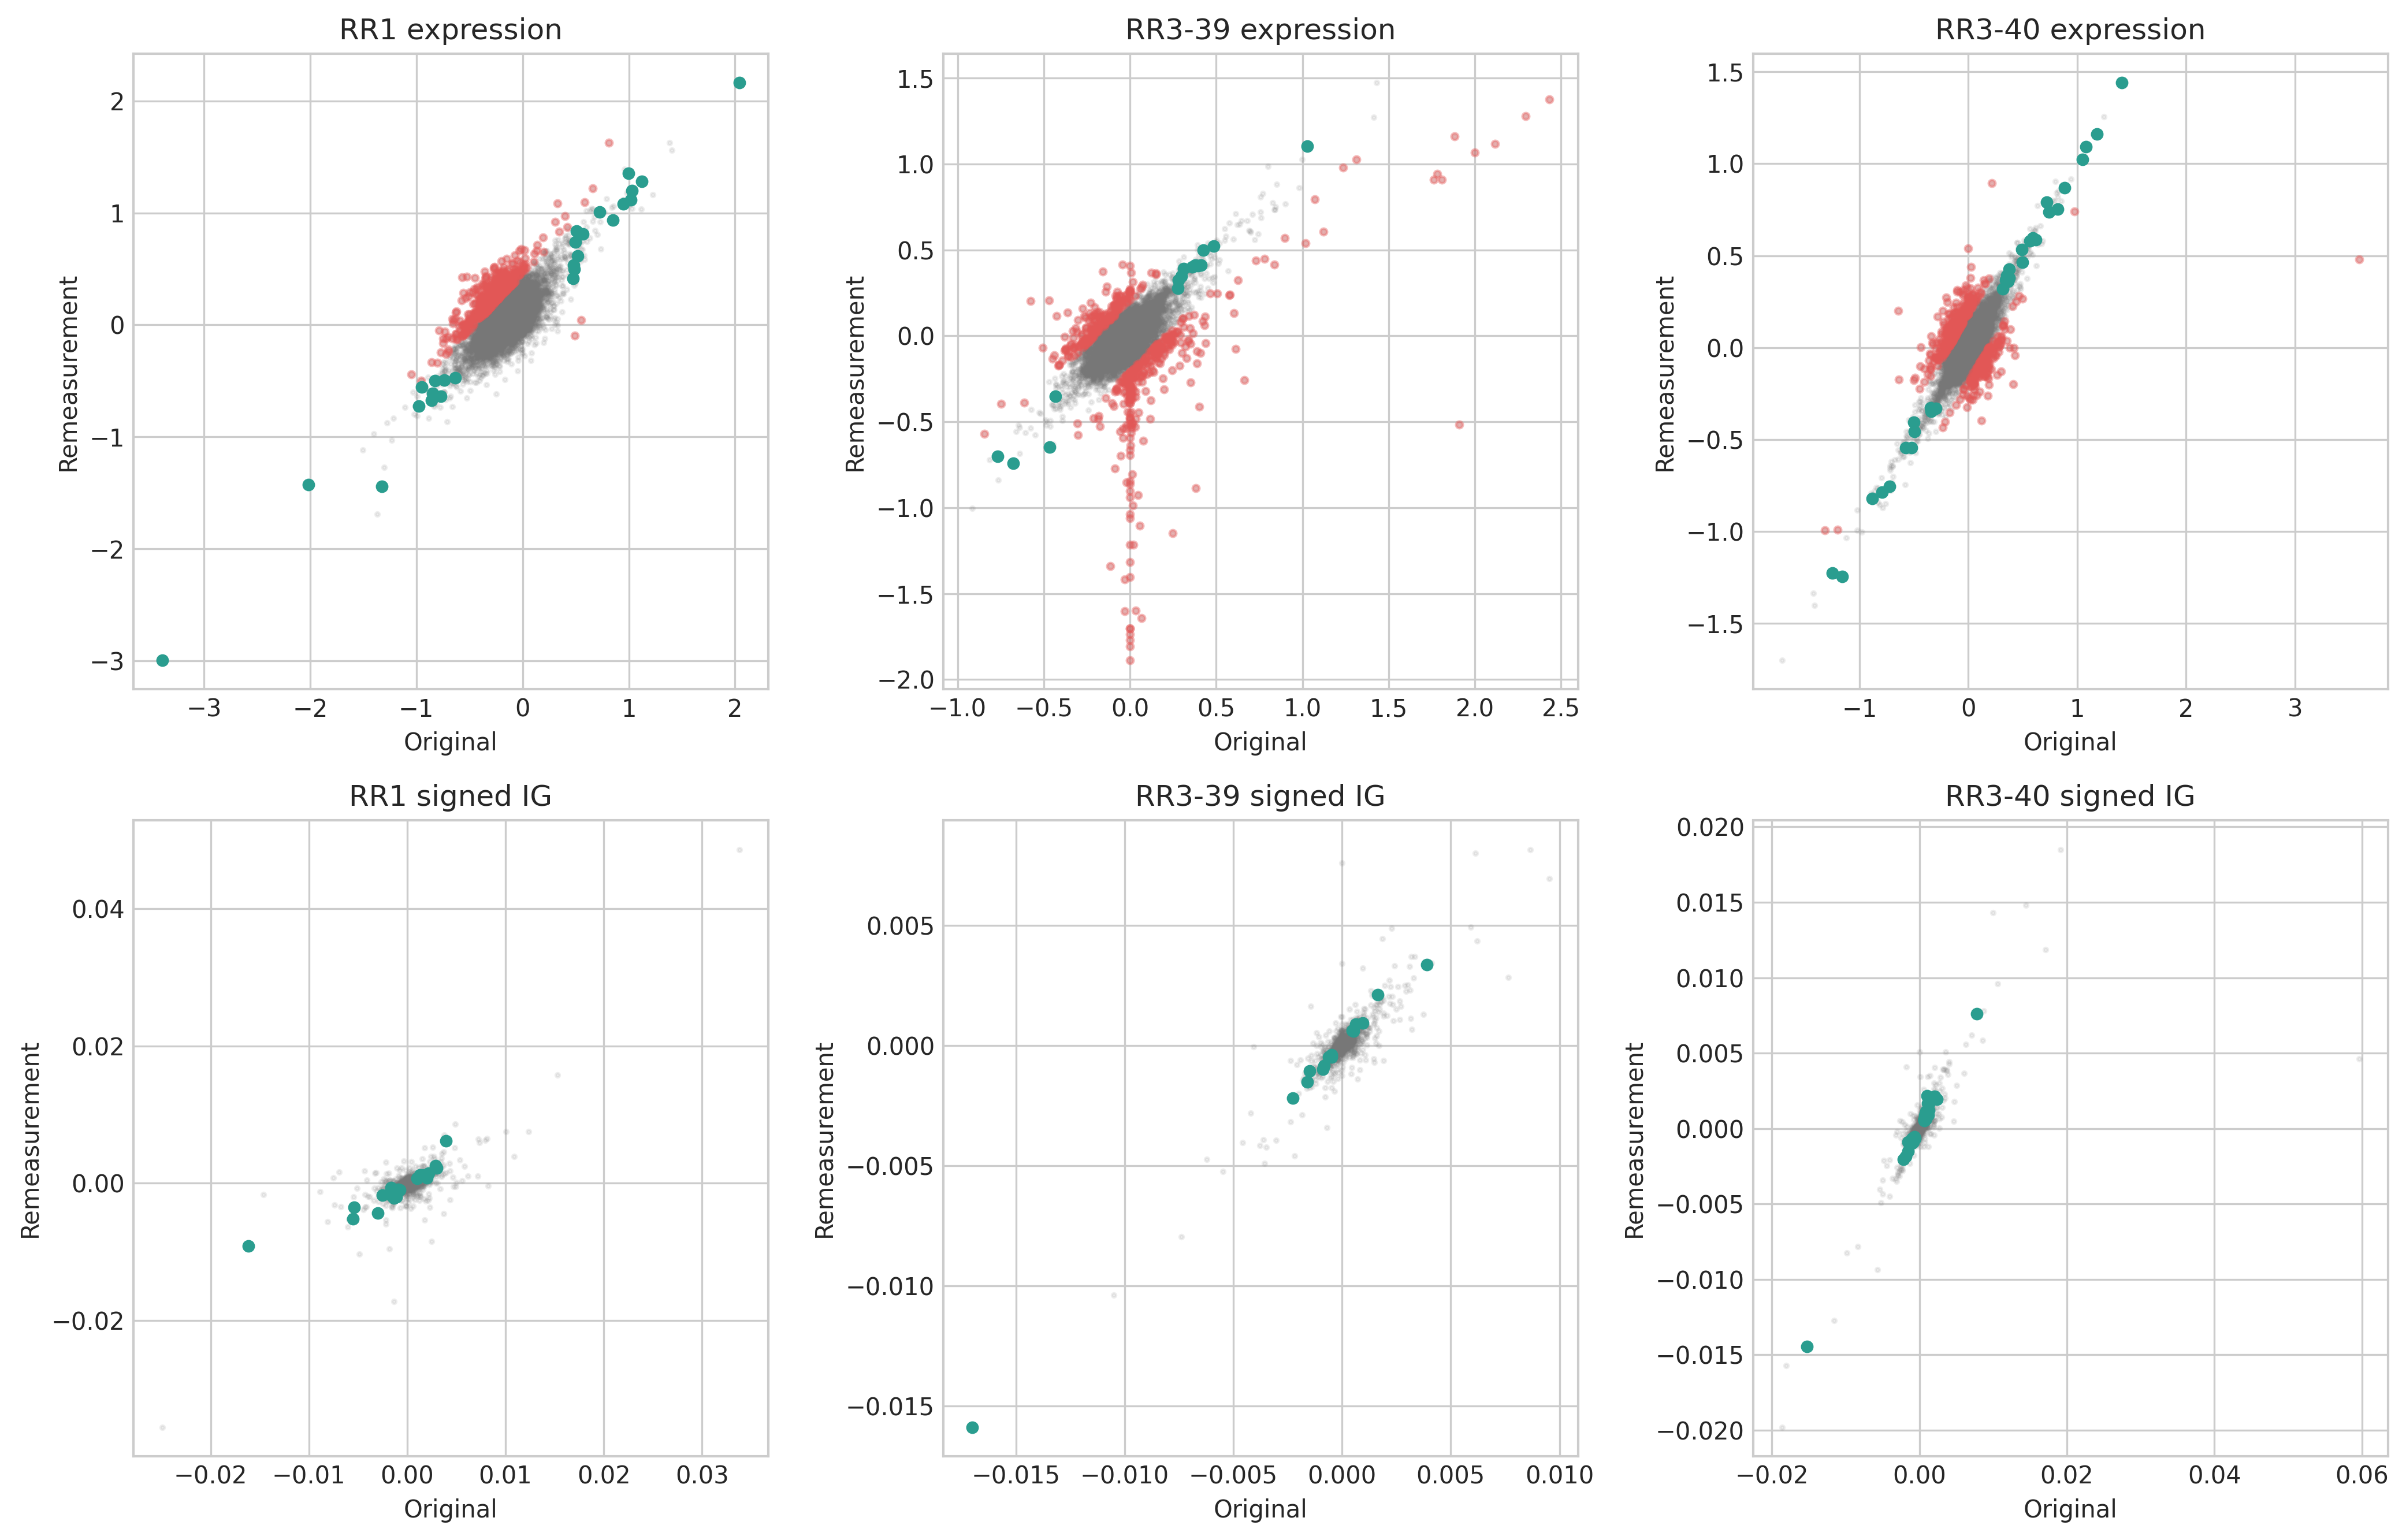

In [5]:
topn = pd.read_csv(ROOT/'benchmarks/rr1_library_prep_interaction/results/robust_core/rr3_controls/topn_overlap.csv')
display(topn.pivot_table(index=['level','top_n'], columns='cohort', values=['overlap','direction_agreement']).style.format({'direction_agreement':'{:.1%}'}, na_rep='—'))
repro = pd.read_csv(ROOT/'benchmarks/rr1_library_prep_interaction/results/robust_core/rr3_controls/multilevel_reproducibility.csv')
display(repro.style.hide(axis='index').format(precision=3, na_rep='—'))
display(Image(filename=str(R/'figures/original_vs_remeasurement.png'), width=1100))

## 4. What BridgeRNA adds

Expression supplies the conventional response baseline. IG asks which input genes influence the frozen latent response; contextual graphs ask whether each gene's local learned neighborhood changes reproducibly. These are multiscale confirmations, not proof that BridgeRNA discovered a raw protocol effect.

cohort,RR1,RR3-39,RR3-40
evidence,,,
Attribution only,180,254,224
Expression + attribution,46,61,110
Expression + attribution + graph,26,15,31
Expression only,85,175,232
Graph only,382,424,390


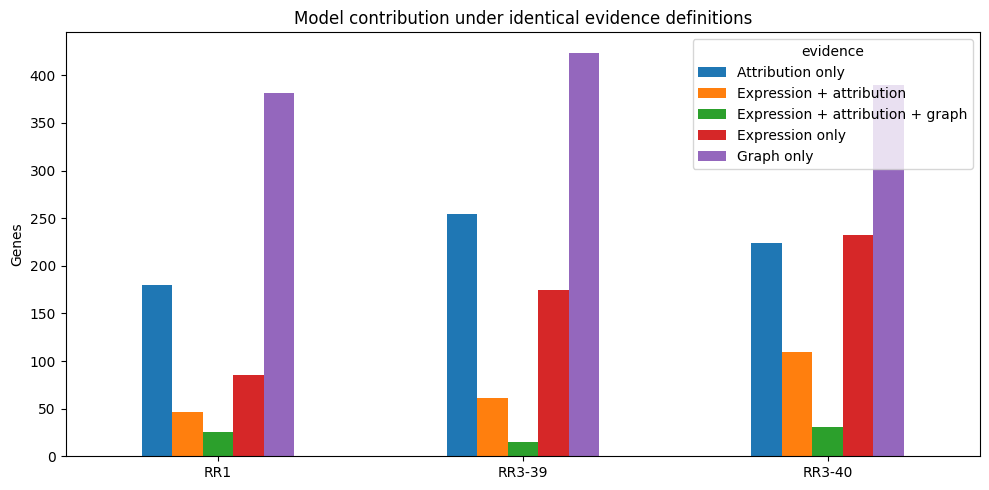

In [6]:
contribution = pd.read_csv(R/'summary/model_contribution.csv')
display(contribution.pivot(index='evidence', columns='cohort', values='genes').fillna(0).astype(int).style)
ax = contribution.pivot(index='cohort', columns='evidence', values='genes').plot.bar(figsize=(10,5))
ax.set(xlabel='', ylabel='Genes', title='Model contribution under identical evidence definitions'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 5. Measurement-sensitive component

For each cohort, `Interaction = ΔX_remeasurement − ΔX_original`; the Top-500 absolute interactions were tested by over-representation analysis against the exact 15,165-gene BridgeRNA universe. These are model-vocabulary expression effects—not a replacement for the existing raw-count edgeR analyses.

In [7]:
sensitive = pd.read_csv(R/'pathways/measurement_sensitive_enrichment.csv')
top_sensitive = (sensitive.query('fdr < 0.05').sort_values(['cohort','fdr']).groupby('cohort').head(8))
display(top_sensitive[['cohort','term','overlap','set_size','fdr']].style.hide(axis='index').format({'fdr':'{:.2e}'}))

cohort,term,overlap,set_size,fdr
RR1,"GO BP: Regulation of mRNA Splicing, via Spliceosome (GO:0048024)",24,98,2.28e-11
RR1,"GO BP: Regulation of Alternative mRNA Splicing, via Spliceosome (GO:0000381)",18,63,1.56e-09
RR1,GO BP: Regulation of RNA Splicing (GO:0043484),21,93,2.07e-09
RR1,GO BP: MRNA Processing (GO:0006397),33,239,2.17e-09
RR1,Reactome: Processing of Capped Intron-Containing Pre-mRNA,32,253,3.94e-08
RR1,Reactome: mRNA Splicing,26,192,4.51e-07
RR1,"GO BP: MRNA Splicing, via Spliceosome (GO:0000398)",27,207,4.51e-07
RR1,"GO BP: RNA Splicing, via Transesterification Reactions With Bulged Adenosine as Nucleophile (GO:0000377)",24,171,7.66e-07
RR3-39,GO BP: Sensory Perception of Light Stimulus (GO:0050953),35,130,2.01e-19
RR3-39,GO BP: Visual Perception (GO:0007601),35,130,2.01e-19


RR1's leading interaction enrichments are consistently **mRNA processing / splicing** terms (FDR down to ~2.3×10⁻¹¹), making this sensitivity especially prominent in RR1. RR3-39 instead has strong light/visual-perception and myogenesis interaction terms; RR3-40 has weaker mitochondrial RNA-processing and immune terms. This does not make RNA processing a pure artifact—it shows that its measured RR1 response is unusually protocol-sensitive.

## 6. Robust and reversing pathways

An existing signed pathway profile is called protocol-robust when it is mutually Top-250 and directionally consistent. Direction-reversing pathways have opposite sign and are Top-250 in at least one measurement. These are contextual/pathway-profile scores, not conventional GSEA NES.

cohort,ambiguous,direction_reversing,original_specific,protocol_robust,remeasurement_specific
RR1,4748,169,92,58,98
RR3-39,4823,6,89,158,89
RR3-40,4876,0,39,211,39


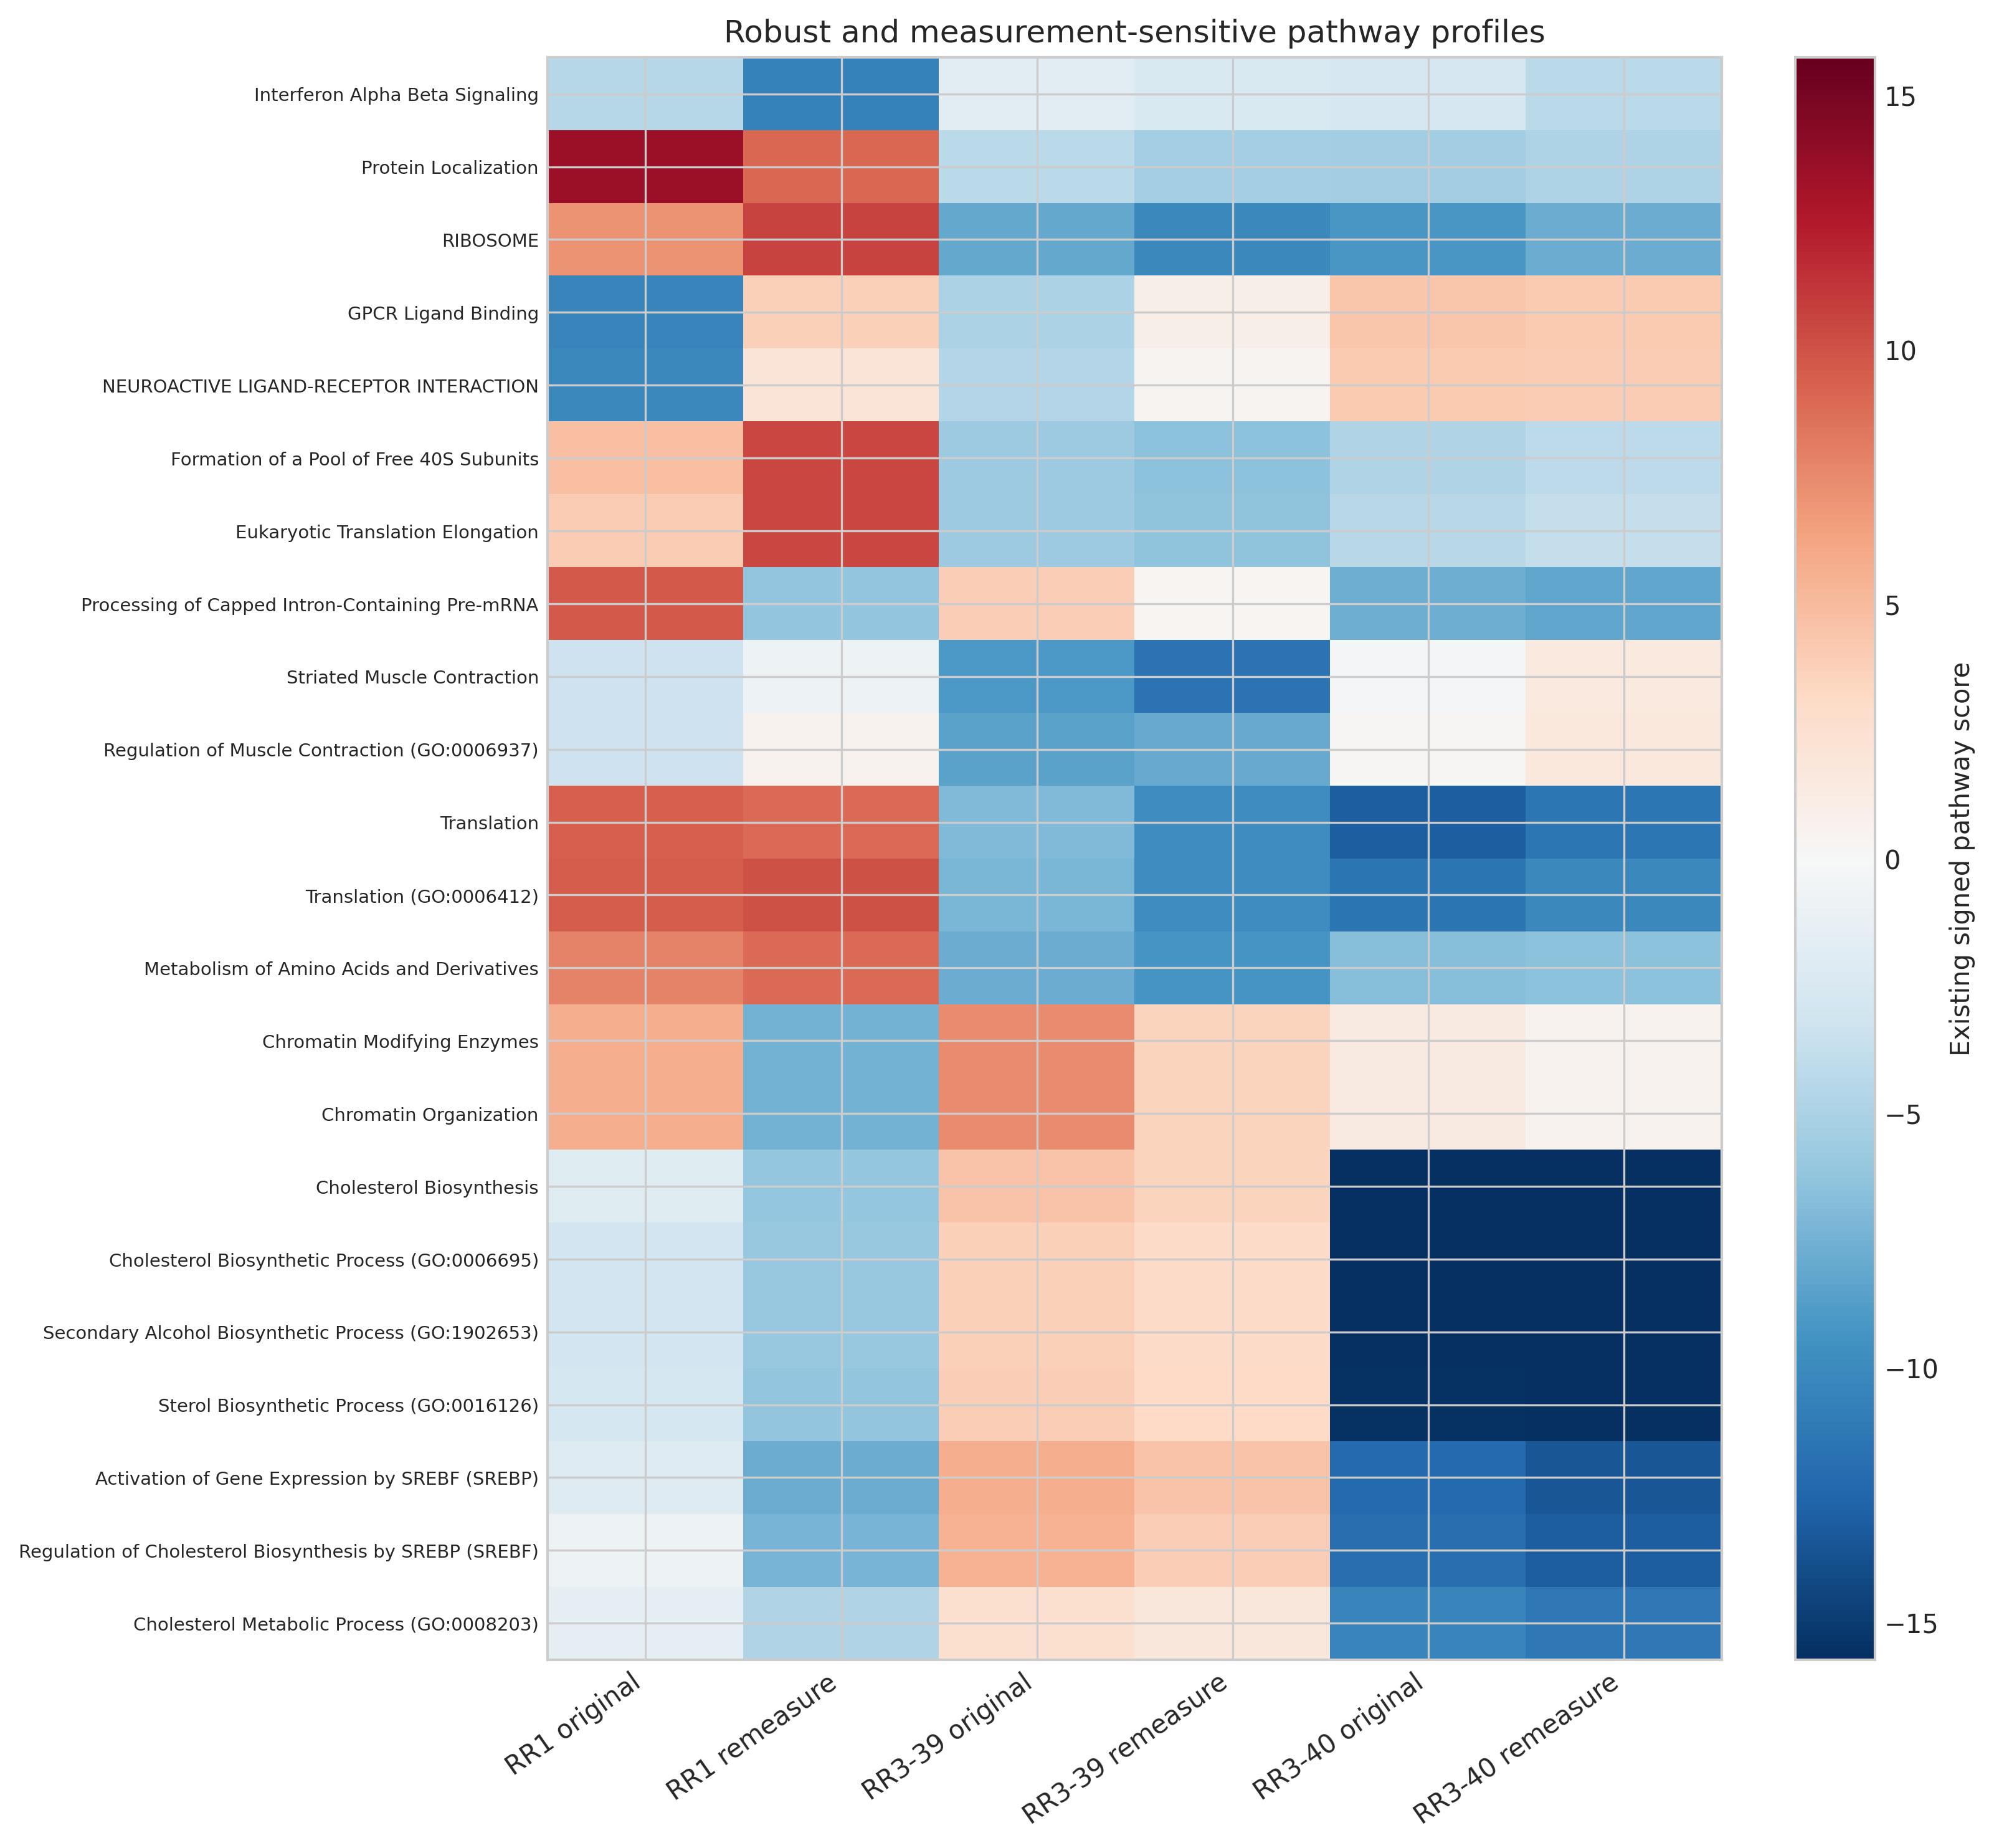

In [8]:
counts = pd.read_csv(R/'summary/pathway_counts.csv')
display(counts.style.hide(axis='index'))
display(Image(filename=str(R/'figures/pathway_profiles.png'), width=1050))

RR1 has only 58 protocol-robust and 169 direction-reversing pathway profiles. RR3-39 has 158 robust and 6 reversing; RR3-40 has 211 robust and none reversing. This is the clearest pathway-scale distinction between the cohorts.

## 7. Shared and cohort-specific biology

In [9]:
bio = pd.read_csv(R/'summary/biological_summary.csv')
shared = json.loads((R/'summary/shared_unique_counts.json').read_text())
display(pd.Series(shared, name='N').to_frame().style)
display(bio.query("feature_type == 'gene' and interpretation == 'shared_all_three'").style.hide(axis='index'))
display(bio.query("feature_type == 'pathway' and interpretation == 'shared_all_three'").head(25).style.hide(axis='index'))

,N
all_three_genes,5
shared_rr3_genes,24
rr1_specific_genes,90
rr3_39_specific_genes,75
rr3_40_specific_genes,134
all_three_pathways,29
shared_rr3_pathways,53


feature_type,gene_or_pathway,interpretation,RR1_robust,RR1_expression_support,RR1_attribution_support,RR1_graph_support,RR3-39_robust,RR3-39_expression_support,RR3-39_attribution_support,RR3-39_graph_support,RR3-40_robust,RR3-40_expression_support,RR3-40_attribution_support,RR3-40_graph_support
gene,GADD45G,shared_all_three,True,True,True,True,True,True,True,False,True,True,True,False
gene,IGFBP1,shared_all_three,True,False,True,True,True,True,True,True,True,True,True,True
gene,NRN1,shared_all_three,True,False,True,True,True,False,True,True,True,False,True,True
gene,SLC41A2,shared_all_three,True,True,True,False,True,True,False,True,True,True,False,True
gene,TCIM,shared_all_three,True,True,True,False,True,True,True,False,True,True,True,False


feature_type,gene_or_pathway,interpretation,RR1_robust,RR1_expression_support,RR1_attribution_support,RR1_graph_support,RR3-39_robust,RR3-39_expression_support,RR3-39_attribution_support,RR3-39_graph_support,RR3-40_robust,RR3-40_expression_support,RR3-40_attribution_support,RR3-40_graph_support
pathway,Aerobic Respiration (GO:0009060),shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Aerobic Respiration and Respiratory Electron Transport,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Cap-dependent Translation Initiation,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Cellular Respiration (GO:0045333),shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Cytoplasmic Translation (GO:0002181),shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Eukaryotic Translation Initiation,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Formation of a Pool of Free 40S Subunits,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,L13a-mediated Translational Silencing of Ceruloplasmin Expression,shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan
pathway,Macromolecule Biosynthetic Process (GO:0009059),shared_all_three,True,nan,nan,nan,True,nan,nan,nan,True,nan,nan,nan


Only five ≥2-level genes are shared by all three comparisons: **GADD45G, IGFBP1, NRN1, SLC41A2, and TCIM**. The shared pathway core is broader (29 profiles), emphasizing respiration/mitochondrial gene expression, translation, and amino-acid metabolism. RR3-39 and RR3-40 share 24 robust genes and 53 robust pathway profiles, consistent with a larger RR3 core despite distinct duration-dependent states. Cohort-specific calls remain candidates rather than universal spaceflight markers.

## 8. Direct answers

1. **How much RR1 survives?** A restricted core survives: 179 expression genes, 246 IG genes, 476 positive local graph neighborhoods, 114 genes supported by ≥2 levels, and 26 by all three. Its global and Hallmark response directions do not reproduce.
2. **Compared with RR3?** RR3-40 is strongest (381 expression genes; 172 ≥2-level; 31 all-three), followed by RR3-39 at the global/pathway scales. RR1 is markedly less reproducible.
3. **Is RR1 uniquely splicing-sensitive?** It is the clearest cohort for measurement-sensitive mRNA processing/splicing enrichment. Related terms occur elsewhere, so “unique” should not be interpreted as exclusive biology.
4. **What is robust in all three?** Five multiscale genes and 29 pathway profiles, chiefly translation, respiration/mitochondrial expression, and amino-acid metabolism.
5. **What is cohort-specific?** 90 RR1-only, 75 RR3-39-only, and 134 RR3-40-only ≥2-level genes under these definitions; these may reflect duration, cohort, or protocol.
6. **Does attribution identify a more stable subset than expression alone?** It supplies orthogonal model evidence and narrows candidates through intersections, but RR1 attribution ranks themselves are weakly reproducible; it does not simply outperform expression.
7. **Does the graph add confirmation?** Yes, at the gene-neighborhood level, but median local agreement remains much lower in RR1 (0.138) than RR3-39/40 (0.340/0.386).
8. **Why does RR3-40 reproduce better?** Numerically it is more concordant at expression, global latent, Hallmark, graph, and pathway levels. The benchmark establishes this association, not a causal mechanism.
9. **Is RR1 failure technical or biological?** Mixed. It coincides with a major protocol transition and strong measurement-sensitive programs, while a smaller concordant biological core remains.
10. **What remains defensible?** A technically reproducible core involving mitochondrial/respiratory, translational, amino-acid metabolic, and a small set of shared genes. Claims should remain at the level of concordant response.

## 9. Limitations and provenance

- OSD-168 is a technical remeasurement, not an independent biological replicate.
- “Protocol-robust” only applies to the compared measurement pair.
- The integrated core counts unweighted agreement across expression, signed input-gene IG, and contextual graph evidence.
- Expression-interaction ORA is restricted to the 15,165-gene universe; it is distinct from full-transcriptome raw-count edgeR/GSEA.
- Pathway-profile scores are reused outputs and should not be described as conventional NES.
- No causal assignment of RR1 instability to one protocol variable is possible from this comparison.